In [1]:
# Restaura el estado de una corrida anterior, si existe el checkpoint.
# (checkpoint.pkl no esta versionado: en una maquina limpia esta celda no hace nada
#  y el notebook se corre entero de todos modos.)
import os
if os.path.exists('checkpoint.pkl'):
    import dill; dill.load_session('checkpoint.pkl')


## 1. Imports

In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## 2. Configuración

In [3]:
np.random.seed(42)
RANDOM_STATE = 42
KFOLDS = 5

FIGS = "figs"
FEATS = "features"
os.makedirs(FIGS, exist_ok=True)
os.makedirs(FEATS, exist_ok=True)

def guardar(nombre):
    ruta = os.path.join(FIGS, nombre)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    print("guardado:", ruta)

def etiqueta_corta(clase):
    return (str(clase).replace("Tomato_", "").replace("Tomato__", "")
                 .replace("_", " ").replace("  ", " ").strip())

## 3. Carga de las matrices de características y conjuntos a comparar

Se cargan las cuatro salidas de 3.6 y se arman las combinaciones a comparar
(LBP solo, HOG solo, LBP+HOG, BoW, Fisher, Propio, y todas concatenadas).

In [4]:
def cargar_npz(nombre):
    return np.load(os.path.join(FEATS, f"{nombre}_features.npz"), allow_pickle=True)

d_lbp_hog = cargar_npz("lbp_hog")
X_lbp_hog, y, N_LBP = d_lbp_hog["X"], d_lbp_hog["y"], int(d_lbp_hog["n_lbp"])
rutas_ref = d_lbp_hog["rutas"]

d_bow = cargar_npz("bow")
d_fisher = cargar_npz("fisher")
d_propio = cargar_npz("propio")

assert (d_bow["rutas"] == rutas_ref).all()
assert (d_fisher["rutas"] == rutas_ref).all()
assert (d_propio["rutas"] == rutas_ref).all()

CONJUNTOS_DESCRIPTORES = {
    "LBP":     X_lbp_hog[:, :N_LBP],
    "HOG":     X_lbp_hog[:, N_LBP:],
    "LBP+HOG": X_lbp_hog,
    "BoW":     d_bow["X"],
    "Fisher":  d_fisher["X"],
    "Propio":  d_propio["X"],
}
CONJUNTOS_DESCRIPTORES["Todos"] = np.hstack(
    [d_bow["X"], d_fisher["X"], d_propio["X"], X_lbp_hog]
)

for nombre, X in CONJUNTOS_DESCRIPTORES.items():
    print(f"{nombre:<10} dim = {X.shape[1]}")

LBP        dim = 59
HOG        dim = 1764
LBP+HOG    dim = 1823
BoW        dim = 64
Fisher     dim = 8192
Propio     dim = 16
Todos      dim = 10095


## 4. Estrategia de validación: k-fold estratificado

Como el dataset no trae partición train/test, la métrica se calcula con
k-fold (`KFOLDS = 5`), estratificado. `cross_val_predict` da una
predicción out-of-fold de cada imagen, o sea, nunca predice con un modelo que la
vio en entrenamiento, y sobre eso se calculan accuracy, F1 por clase y la
matriz de confusión.

In [5]:
kfold = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=RANDOM_STATE)

def evaluar(modelo, X_sub, y_eval, kfold=kfold):
    y_pred = cross_val_predict(modelo, X_sub, y_eval, cv=kfold)
    acc = accuracy_score(y_eval, y_pred)
    f1_macro = f1_score(y_eval, y_pred, average="macro")
    reporte = classification_report(y_eval, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_eval, y_pred, labels=sorted(set(y_eval)))
    return dict(accuracy=acc, f1_macro=f1_macro, reporte=reporte, cm=cm, y_pred=y_pred)

RESULTADOS = []

## 5. k-Nearest Neighbors

Varios valores de `k` obviamente impares sobre cada conjunto de descriptores,
con features estandarizadas.

In [6]:
VALORES_K = [3, 5, 7, 9, 11]
knn_filas = []

for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    for k in VALORES_K:
        modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
        r = evaluar(modelo, X_sub, y)
        knn_filas.append({"descriptor": nombre_desc, "k": k,
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
        RESULTADOS.append({"descriptor": nombre_desc, "modelo": f"kNN (k={k})", **r})

df_knn = pd.DataFrame(knn_filas)
df_knn.pivot(index="k", columns="descriptor", values="accuracy").round(3)

descriptor,BoW,Fisher,HOG,LBP,LBP+HOG,Propio,Todos
k,,,,,,,
3,0.550,0.775,0.388,0.681,0.450,0.638,0.688
5,0.562,0.788,0.394,0.700,0.438,0.650,0.775
7,0.562,0.738,0.406,0.681,0.462,0.612,0.769
9,0.569,0.775,0.356,0.669,0.406,0.638,0.750
11,0.562,0.750,0.356,0.656,0.394,0.594,0.725


## 6. Support Vector Machines

Tres kernels; se reporta el mejor por conjunto de descriptores.

In [7]:
KERNELS = ["linear", "rbf", "poly"]
svm_filas = []

for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    for kernel in KERNELS:
        modelo = make_pipeline(StandardScaler(), SVC(kernel=kernel, random_state=RANDOM_STATE))
        r = evaluar(modelo, X_sub, y)
        svm_filas.append({"descriptor": nombre_desc, "kernel": kernel,
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
        RESULTADOS.append({"descriptor": nombre_desc, "modelo": f"SVM ({kernel})", **r})

df_svm = pd.DataFrame(svm_filas)
df_svm.pivot(index="kernel", columns="descriptor", values="accuracy").round(3)

descriptor,BoW,Fisher,HOG,LBP,LBP+HOG,Propio,Todos
kernel,,,,,,,
linear,0.575,0.831,0.669,0.594,0.725,0.650,0.850
poly,0.512,0.369,0.256,0.600,0.262,0.550,0.250
rbf,0.581,0.806,0.694,0.688,0.706,0.719,0.856


## 7. Random Forest, XGBoost y LightGBM

Ninguno de los tres necesita escalado.

In [8]:
le = LabelEncoder().fit(y)
arboles_filas = []

In [9]:
for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    modelo = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    r = evaluar(modelo, X_sub, y)
    arboles_filas.append({"descriptor": nombre_desc, "modelo": "RandomForest",
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
    RESULTADOS.append({"descriptor": nombre_desc, "modelo": "RandomForest", **r})

In [10]:
for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    modelo = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric="mlogloss")
    r = evaluar(modelo, X_sub, le.transform(y))
    arboles_filas.append({"descriptor": nombre_desc, "modelo": "XGBoost",
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
    RESULTADOS.append({"descriptor": nombre_desc, "modelo": "XGBoost", **r})

Unable to determine the device handle for GPU0: 0000:01:00.0: Unknown Error


In [11]:
for nombre_desc, X_sub in CONJUNTOS_DESCRIPTORES.items():
    modelo = LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, verbosity=-1)
    r = evaluar(modelo, X_sub, y)
    arboles_filas.append({"descriptor": nombre_desc, "modelo": "LightGBM",
                           "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]})
    RESULTADOS.append({"descriptor": nombre_desc, "modelo": "LightGBM", **r})

df_arboles = pd.DataFrame(arboles_filas)
df_arboles.pivot(index="modelo", columns="descriptor", values="accuracy").round(3)

descriptor,BoW,Fisher,HOG,LBP,LBP+HOG,Propio,Todos
modelo,,,,,,,
LightGBM,0.588,0.675,0.612,0.644,0.731,0.700,0.869
RandomForest,0.619,0.725,0.706,0.662,0.762,0.694,0.819
XGBoost,0.512,0.594,0.550,0.625,0.712,0.688,0.806


## 8. Comparación de descriptores y modelos

In [12]:
tabla_resultados = pd.DataFrame([
    {"descriptor": r["descriptor"], "modelo": r["modelo"],
     "accuracy": r["accuracy"], "f1_macro": r["f1_macro"]}
    for r in RESULTADOS
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

tabla_resultados.to_csv(os.path.join(FEATS, "resultados_clasificacion.csv"), index=False)
tabla_resultados.head(10)

,descriptor,modelo,accuracy,f1_macro
0,Todos,LightGBM,0.86875,0.864987
1,Todos,SVM (rbf),0.85625,0.855369
2,Todos,SVM (linear),0.85000,0.848894
3,Fisher,SVM (linear),0.83125,0.829710
4,Todos,RandomForest,0.81875,0.813788
5,Todos,XGBoost,0.80625,0.795433
6,Fisher,SVM (rbf),0.80625,0.804776
7,Fisher,kNN (k=5),0.78750,0.784609
8,Fisher,kNN (k=9),0.77500,0.773126
9,Fisher,kNN (k=3),0.77500,0.774208


guardado: figs/07_comparacion_descriptores.png


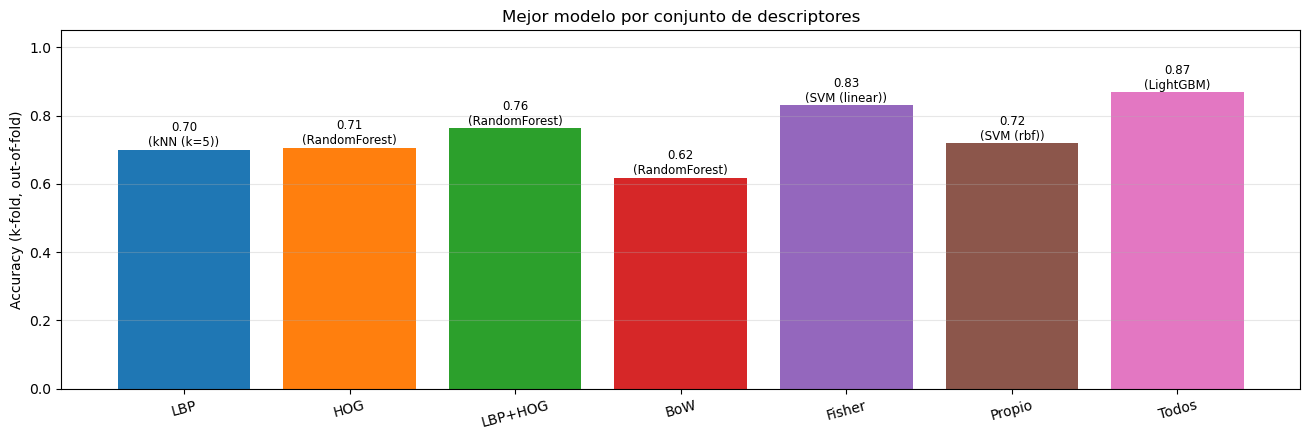

In [13]:
orden_descriptores = list(CONJUNTOS_DESCRIPTORES.keys())
mejor_por_descriptor = (tabla_resultados.sort_values("accuracy", ascending=False)
                                        .groupby("descriptor").first()
                                        .reindex(orden_descriptores))

fig, ax = plt.subplots(figsize=(1.6 * len(orden_descriptores) + 2, 4.5))
colores = plt.cm.tab10.colors
ax.bar(mejor_por_descriptor.index, mejor_por_descriptor["accuracy"],
       color=[colores[i % len(colores)] for i in range(len(mejor_por_descriptor))])
for i, (acc, modelo) in enumerate(zip(mejor_por_descriptor["accuracy"], mejor_por_descriptor["modelo"])):
    ax.text(i, acc + 0.01, f"{acc:.2f}\n({modelo})", ha="center", fontsize=8.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy (k-fold, out-of-fold)")
ax.set_title("Mejor modelo por conjunto de descriptores")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
guardar("07_comparacion_descriptores.png")
plt.show()

guardado: figs/08_matriz_confusion_mejor_modelo.png


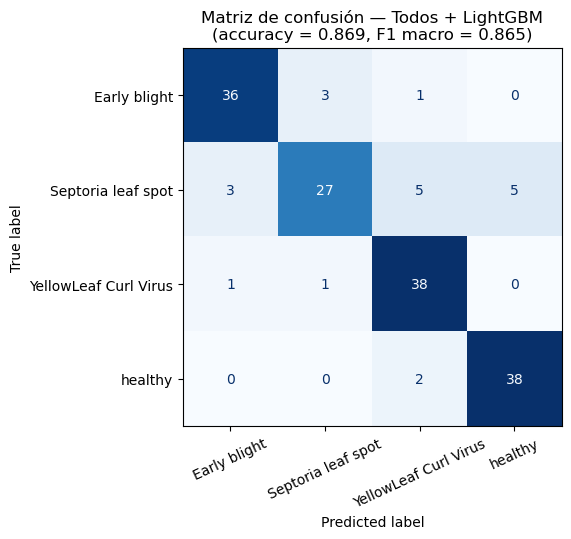

  Early blight             F1 = 0.900
  Septoria leaf spot       F1 = 0.761
  YellowLeaf Curl Virus    F1 = 0.884
  healthy                  F1 = 0.916


In [14]:
mejor_global = next(r for r in RESULTADOS
                     if r["descriptor"] == tabla_resultados.iloc[0]["descriptor"]
                     and r["modelo"] == tabla_resultados.iloc[0]["modelo"])

clases_orden = list(le.classes_) if mejor_global["modelo"] == "XGBoost" else sorted(set(y))
etiquetas_cortas = [etiqueta_corta(c) for c in clases_orden]

disp = ConfusionMatrixDisplay(confusion_matrix=mejor_global["cm"], display_labels=etiquetas_cortas)
fig, ax = plt.subplots(figsize=(6, 5.5))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=25, colorbar=False)
ax.set_title(f"Matriz de confusión — {tabla_resultados.iloc[0]['descriptor']} "
             f"+ {tabla_resultados.iloc[0]['modelo']}\n"
             f"(accuracy = {mejor_global['accuracy']:.3f}, F1 macro = {mejor_global['f1_macro']:.3f})")
plt.tight_layout()
guardar("08_matriz_confusion_mejor_modelo.png")
plt.show()

for c in clases_orden:
    key = str(c)
    if key in mejor_global["reporte"]:
        print(f"  {etiqueta_corta(c):<24} F1 = {mejor_global['reporte'][key]['f1-score']:.3f}")

## 9. Conclusiones

El mejor resultado global lo da el conjunto **"Todos"** (BoW + Fisher + Propio +
LBP+HOG concatenados) con **LightGBM**: accuracy = 0.869, F1 macro = 0.865 en
validación k-fold (k=5, out-of-fold). Detrás quedan SVM rbf (0.856) y SVM lineal
(0.850) sobre el mismo conjunto. Es decir, combinar todos los descriptores ayuda, y
esto se puede ver porque del top 10, 5 son del conjunto "Todos", el resto de fisher.
Pero el salto más grande ya lo da el descriptor Fisher por sí solo (accuracy ≈ 0.83):
captura mucha de la información relevante para distinguir las 4 clases incluso sin
combinarlo con nada más.

LBP+HOG combinados (0.762 con Random Forest) no superan a Fisher ni a "Todos": la
textura+forma que capturan no alcanza para separar bien las clases más parecidas
visualmente. Lo que sí consiguen es mejorar a cada uno por separado (LBP 0.700, HOG
0.706), o sea que se complementan, porque LBP mide microtextura sin información
espacial y HOG la disposición de los gradientes. Vale aclarar que estos números
corresponden a la versión actual de 3.6, donde los dos descriptores se calculan sobre
la imagen en escala de grises **completa**, sin aplicar la máscara de segmentación (que
es la formulación estándar de ambos operadores), y donde LBP usa la variante uniforme
de 59 bins. En la corrida anterior, con los dos descriptores enmascarados, HOG rendía
0.581 y la combinación quedaba por debajo de LBP solo: el borde artificial que
introduce poner el fondo a 0 era el gradiente más fuerte de la imagen y terminaba
dominando el descriptor. BoW es consistentemente el descriptor más débil de los seis:
al ser un histograma de "palabras visuales" sin información espacial, pierde detalle
que sí aportan Fisher que guarda momentos de primer y segundo orden por cada palabra
visual, o sea mas detalle, o como el descriptor propio que usa directamente color e
info de textura o forma de la lesión.

Ahora, sobre los modelos, no hay uno que domine en todos los conjuntos. Promediando
sobre los siete, SVM rbf queda primero (0.721), seguido de Random Forest (0.712) y SVM
lineal (0.699); LightGBM (0.688) y XGBoost (0.641) quedan detrás, y kNN (≈0.60) y el
kernel polinómico más abajo todavía, este último es el peor por lejos con 0.400. Pero
en el conjunto de más dimensiones, "Todos" (10095 columnas), se da vuelta: ahí LightGBM
es el mejor de todos con 0.869, por encima de SVM rbf (0.856) y de Random Forest
(0.819), y XGBoost llega a 0.806. O sea que los dos modelos de boosting necesitan la
concatenación completa para rendir, mientras que en los conjuntos individuales Random
Forest sigue siendo el más regular de los tres modelos de árboles.

La matriz de confusión del mejor modelo muestra que el error se concentra en **Septoria
leaf spot**, la única clase claramente por debajo del resto (F1 = 0.761, 27 de 40
imágenes bien clasificadas). Sus errores se reparten: 3 se van a **Early blight**, algo
esperable porque ambas son manchas necróticas de tono marrón/oscuro sobre la hoja,
visualmente parecidas incluso para el ojo humano, pero otras 5 se van a **YellowLeaf**
y 5 a **hoja sana**. Esto último tiene sentido si se piensa que las lesiones de septoria
son manchas chicas y dispersas, así que una hoja poco afectada termina pareciéndose
bastante a una sana. Las otras tres clases andan bien y parejas: hoja sana (F1 = 0.916),
Early blight (0.900) y virus del rizado amarillo (0.884), que tienen un patrón de color
y forma más distintivo.

Finalmente, respecto a las limitaciones, los resultados vienen de un subconjunto local del dataset
PlantVillage (4 clases de tomate), no de las ~15 clases completas del dataset
original, así que estos números no se pueden comparar directamente con
benchmarks publicados sobre PlantVillage completo. Tampoco hice búsqueda de
hiperparámetros, esto porque considere que el objetivo del proyecto no es hallar el mejor modelo, simplemente demostrar que los descriptores, pues funcionan
así que hay margen para mejorar accuracy ajustando, por ejemplo, `C`/`gamma`
en SVM o la profundidad de los árboles tambien. 
